# 01 — Data Exploration

Load raw ECG data from the ECG Arrhythmia Database, inspect signal quality, visualise examples from each class, and run the preprocessing pipeline.

This notebook explores the [PhysioNet ECG Arrhythmia Database](https://physionet.org/content/ecg-arrhythmia/1.0.0/) — a large, publicly available 12-lead ECG dataset with physician-validated SNOMED-CT diagnostic labels, making it well suited for multi-label arrhythmia classification research.

**Prerequisites:** before running this notebook, execute `python download_dataset.py` to fetch the raw data and `python preprocess_dataset.py` to generate the metadata CSV and cached `.npy` signal files.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import wfdb

from src.data.dataset import ArrhythmiaDataset, ARRHYTHMIA_CLASSES
from src.data.preprocessing import preprocess

with open('../configs/data.yaml') as f:
    cfg = yaml.safe_load(f)

DATA_DIR = '../' + cfg['dataset']['raw_dir']
FS = cfg['signal']['sample_rate']
DURATION = cfg['signal']['duration']
CLASSES = cfg['labels']['classes']
SEED = cfg['splits']['seed']
print(f"Data dir : {DATA_DIR}")
print(f"Sample rate: {FS} Hz  |  Duration: {DURATION} s")
print(f"Classes: {CLASSES}")

Data dir : ../data/raw/ecg-arrhythmia
Sample rate: 500 Hz  |  Duration: 10 s
Classes: ['SB', 'SR', 'AF', 'ST', 'TWC']


## Load arrhythmia metadata

In [2]:
meta = pd.read_csv('../data/processed/arrhythmia_metadata.csv')
print(f"Total records: {len(meta):,}")
print(f"\nColumns: {list(meta.columns)}")
meta[['age', 'sex']].describe()

Total records: 45,141

Columns: ['record_id', 'record_path', 'snomed_codes', 'abbreviations', 'age', 'sex']


,age
count,45086.000000
mean,58.209599
std,19.688547
min,0.000000
25%,48.000000
50%,61.000000
75%,72.000000
max,89.000000


## Label distribution across arrhythmia classes

Record counts per class:
  SB: 16,559
  SR: 8,114
  AF: 8,060
  ST: 7,255
  TWC: 7,043


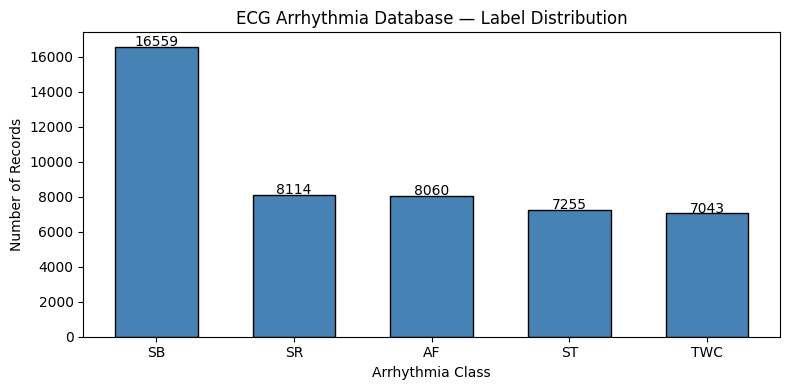

In [3]:
counts = {cls: 0 for cls in CLASSES}

for abbrevs in meta['abbreviations'].dropna():
    abbrev_set = set(abbrevs.split(','))
    for cls in CLASSES:
        if cls in abbrev_set:
            counts[cls] += 1

print("Record counts per class:")
for k, v in counts.items():
    print(f"  {k}: {v:,}")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black', width=0.6)
ax.set_xlabel('Arrhythmia Class')
ax.set_ylabel('Number of Records')
ax.set_title('ECG Arrhythmia Database — Label Distribution')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 40, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Visualise 12-lead ECG - One sample from test set

Skipping 1 records with missing .npy cache files
Signal shape: (12, 5000)  (leads x timesteps)
Labels: ['SB']


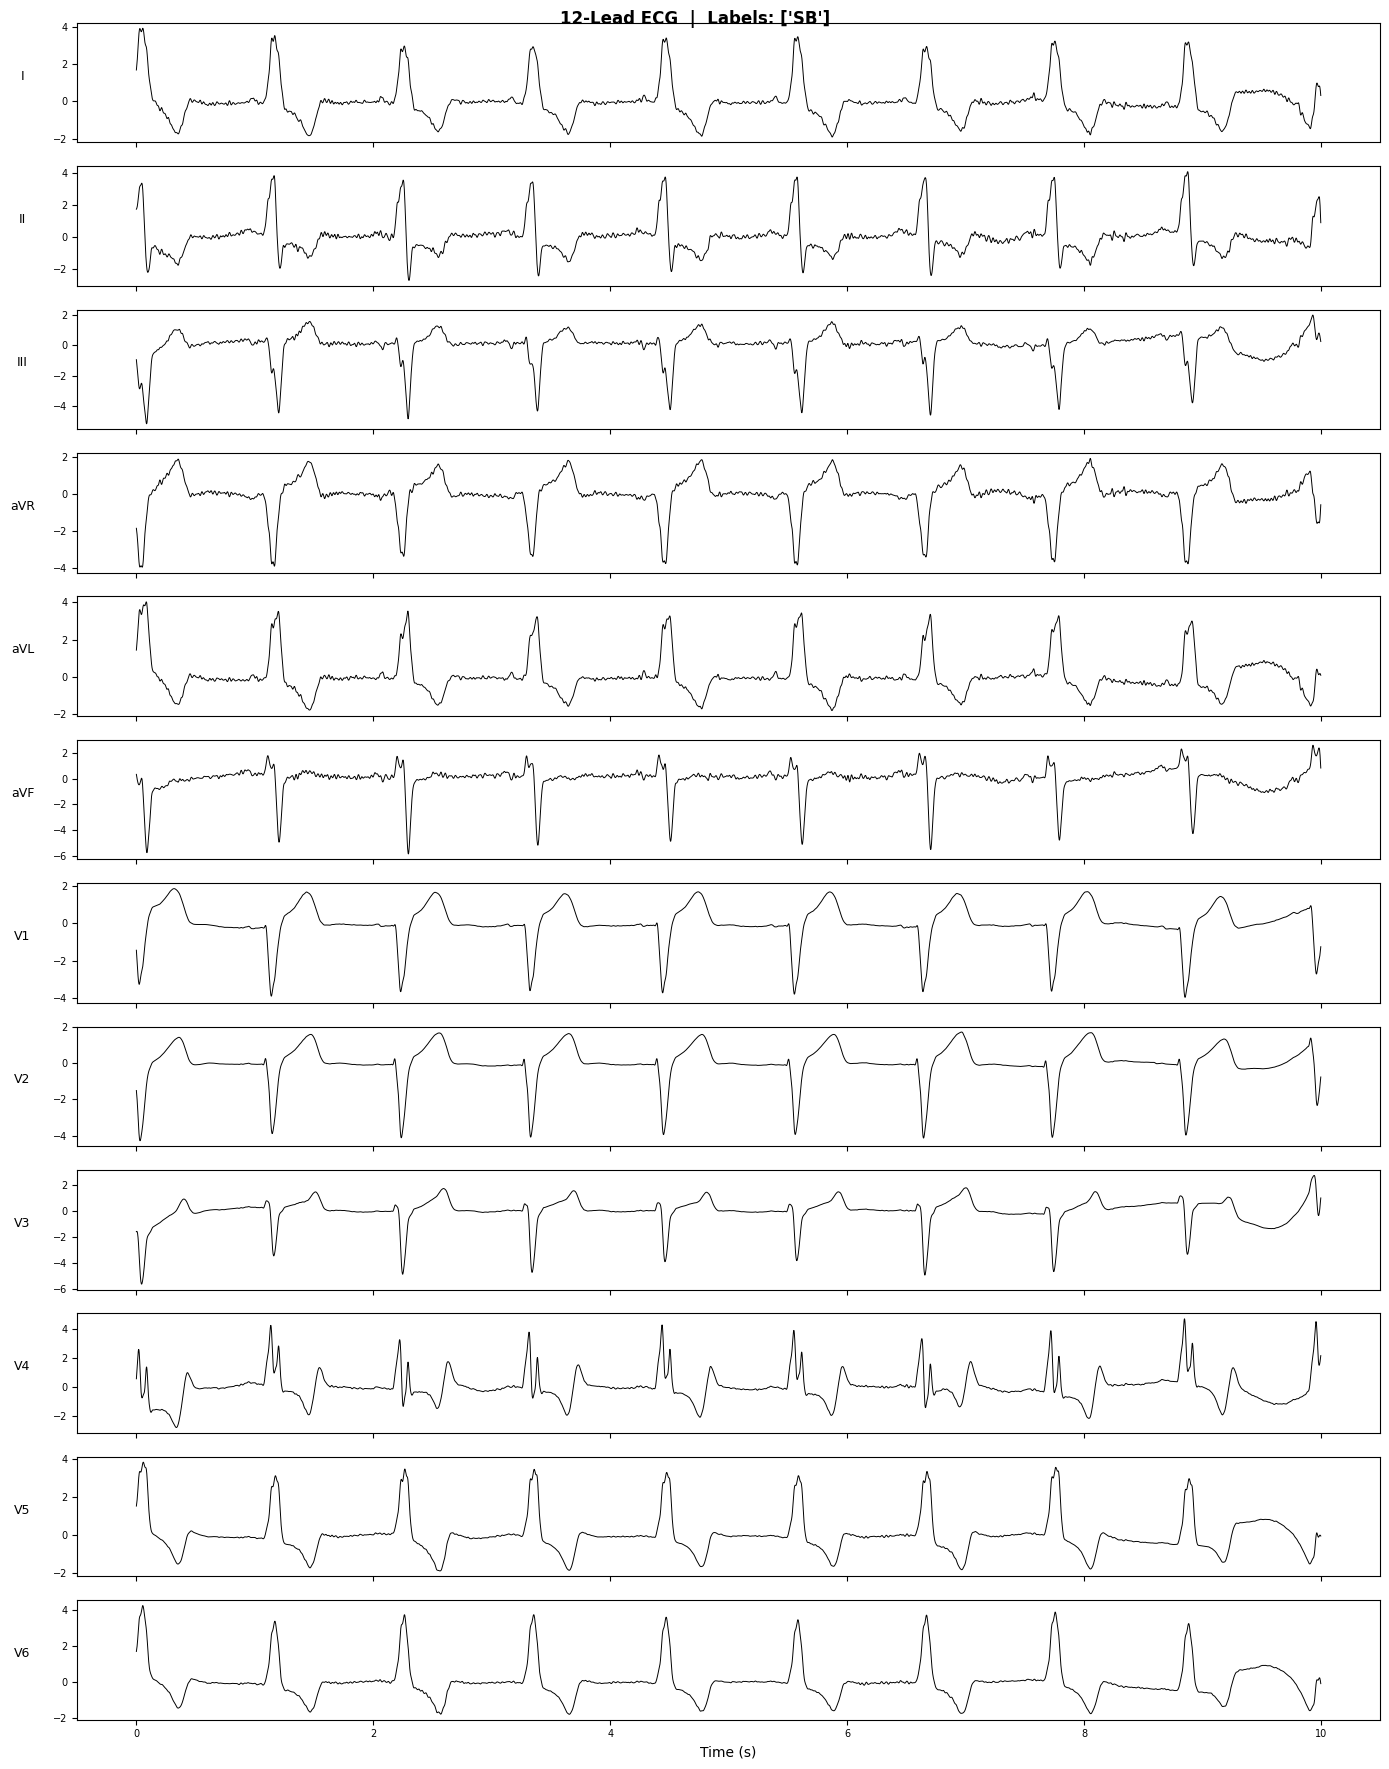

In [4]:
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

cache_dir = f'../data/preprocessed/{FS}'
dataset = ArrhythmiaDataset(
    DATA_DIR, split='test', classes=CLASSES, seed=SEED,
    cache_dir=cache_dir, sampling_rate=FS,
    metadata_path='../data/processed/arrhythmia_metadata.csv',
)
signal, label = dataset[0]
label_str = [CLASSES[i] for i in range(len(label)) if label[i] == 1.0]

print(f"Signal shape: {tuple(signal.shape)}  (leads x timesteps)")
print(f"Labels: {label_str if label_str else ['none']}")

time = np.arange(signal.shape[1]) / FS
fig, axes = plt.subplots(12, 1, figsize=(14, 18), sharex=True)

for i, (ax, lead_name) in enumerate(zip(axes, LEAD_NAMES)):
    ax.plot(time, signal[i].numpy(), linewidth=0.7, color='black')
    ax.set_ylabel(lead_name, fontsize=9, rotation=0, labelpad=22)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'12-Lead ECG  |  Labels: {label_str}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Raw vs. Preprocessed signal (lead II)

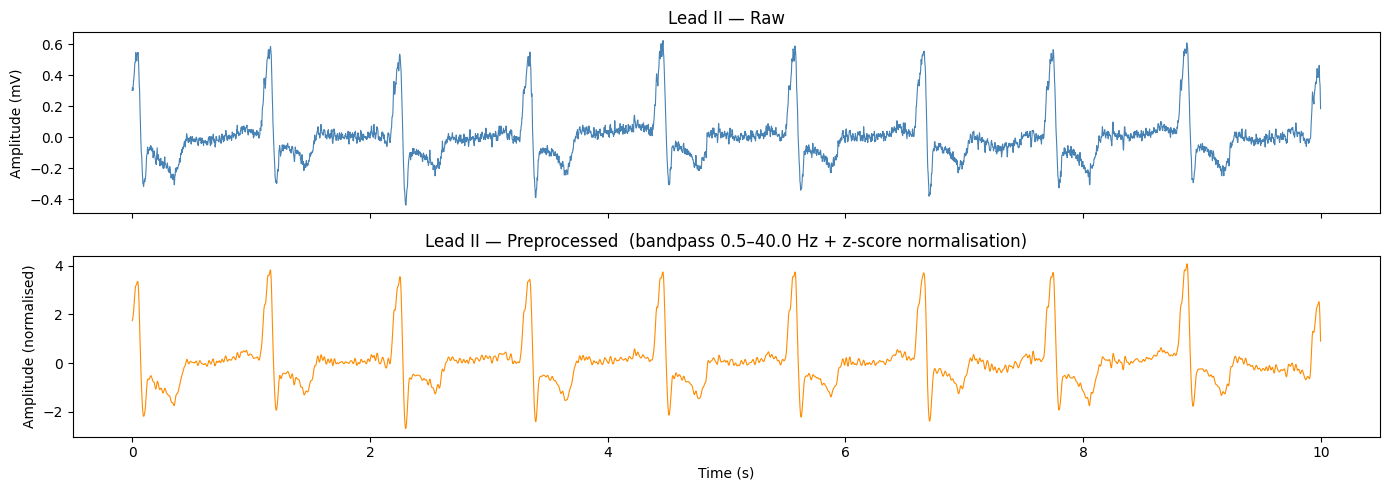

In [5]:
row = dataset.meta.iloc[0]
record_path = f"{DATA_DIR}/{row['record_path']}"
raw, _ = wfdb.rdsamp(record_path)
raw_lead2 = raw[:, 1].astype('float32')          # Lead II
processed_lead2 = preprocess(
    raw_lead2,
    fs=float(FS),
    duration=float(DURATION),
    lowcut=cfg['preprocessing']['bandpass_lowcut'],
    highcut=cfg['preprocessing']['bandpass_highcut'],
)
time = np.arange(len(raw_lead2)) / FS
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(time, raw_lead2, linewidth=0.8, color='steelblue')
axes[0].set_title('Lead II — Raw')
axes[0].set_ylabel('Amplitude (mV)')
axes[1].plot(time, processed_lead2, linewidth=0.8, color='darkorange')
axes[1].set_title(
    f"Lead II — Preprocessed  "
    f"(bandpass {cfg['preprocessing']['bandpass_lowcut']}–"
    f"{cfg['preprocessing']['bandpass_highcut']} Hz + z-score normalisation)"
)
axes[1].set_ylabel('Amplitude (normalised)')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()